**I.I. Beterov, K.V.Kozenko, P.Xu, I.I. Ryabtsev. This notebook studies three-photon counterdiabatic gate in comparison with Levine-Pichler, time-optimal and amplitude-robust gate protocols. Effect of finite blockade strenght, robustness to variation of Rabi frequency and effect of spontaneous decay are investigated.  We use Rydopt 0.2.0 package David F. Locher, Josias Old, Katharina Brechtelsbauer, Jakob Holschbach, Hans Peter Büchler, Sebastian Weber, Markus Müller, Multiqubit Rydberg Gates for Quantum Error Correction, arXiv:2512.00843**

In [1]:
import rydopt as ro
import numpy as np
import jax.numpy as jnp
import matplotlib.pyplot as plt
from rydopt.types import HamiltonianFunction


C:\ProgramData\anaconda3\envs\RydOp\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


**Pulse functions for Levine-Pichler and countediabatic gate**

In [2]:
def phase_step(t: jnp.ndarray | float, duration: float, ansatz_params: jnp.ndarray) -> jnp.ndarray:
    phase = ansatz_params[0]
    return phase*jnp.heaviside(t-duration/2,1)

def double_sin(t: jnp.ndarray | float, duration: float, ansatz_params: jnp.ndarray) -> jnp.ndarray:
    amplitude1 = ansatz_params[0]
    if len(ansatz_params)>1:
        amplitude2=ansatz_params[1]
    else: 
        amplitude2=amplitude1
    t1=0.25*duration
    t2=0.75*duration
    return amplitude1*jnp.sin(2*jnp.pi*(t-t1)/duration)*jnp.heaviside(duration/2-t,0)+amplitude2*jnp.sin(2*jnp.pi*(t-t2)/duration)*jnp.heaviside(t-duration/2,1)



def double_exp(t: jnp.ndarray | float, duration: float, ansatz_params: jnp.ndarray) -> jnp.ndarray:
    amplitude1 = ansatz_params[0]
    if len(ansatz_params)>1:
        amplitude2=ansatz_params[1]
    else: 
        amplitude2=amplitude1
    t1=0.25*duration
    t2=0.75*duration
    wt=0.125*duration
    return amplitude1*jnp.exp(-((t-t1)/wt)**4)*jnp.heaviside(duration/2-t,0)+amplitude2*jnp.exp(-((t-t2)/wt)**4)*jnp.heaviside(t-duration/2,1)


def counterdia(t: jnp.ndarray | float, duration: float, ansatz_params: jnp.ndarray) -> jnp.ndarray:
    if len(ansatz_params)>2:
        RabiArray = ansatz_params[0::2]
        Rabi1=RabiArray[0]
        Rabi2=RabiArray[1]
    else: 
        Rabi1=ansatz_params[0]
        Rabi2=Rabi1

    if len(ansatz_params)>3:    
        detuningArray= ansatz_params[1::2]
        detuning1=detuningArray[0]
        detuning2=detuningArray[1]
    else:
        detuning1=ansatz_params[1]
        detuning2=detuning1
    t1=0.25*duration
    t2=0.75*duration
    wt=0.125*duration
    
    
    def Delta(t,t_c=0.0,detuning=detuning1):
        return detuning*(jnp.sin(2*jnp.pi*(t-t_c)/duration))
                         
    def OmegaRe(t,t_c=0.0,Rabi=Rabi1):
        return Rabi*(jnp.exp(-((t-t_c)/wt)**4))
                     
    def Derive(t,t_c=0.0,Rabi=Rabi1,detuning=detuning1):
        return (Delta(t,t_c,detuning)*Rabi*4*((t-t_c)**3)*jnp.exp(-((t-t_c)/wt)**4)/(wt**4)+OmegaRe(t,t_c,Rabi)*detuning*2*jnp.pi*jnp.cos(2*jnp.pi*(t-t_c)/duration)/duration)/(OmegaRe(t,t_c,Rabi1)**2+Delta(t,t_c,detuning1)**2)
                     
           
    return jnp.heaviside(duration/2-t,0)*Derive(t,t1,Rabi1,detuning1)+jnp.heaviside(t-duration/2,1)*Derive(t,t2,Rabi2,detuning2)    

**Three-photon counterdiabatic gate for finite blockade strength and spontaneous decay**

In [3]:
class CZGateThreePhotonFull:

    def __init__(self, Omega2: float,  Omega3: float, Vnn: float, DecayP: float, DecayS: float, DecayR: float):
        self._Omega2 = Omega2
        self._Omega3 = Omega3
        self._Vnn = Vnn
        self._DecayP = DecayP
        self._DecayS = DecayS
        self._DecayR = DecayR

        
        
    def initial_basis_states(self) -> tuple[jnp.ndarray, ...]:
        return jnp.array([1,0,0,0], dtype=complex), jnp.array([1,0,0,0,0,0,0,0,0,0], dtype=complex)

    def hamiltonian_functions_for_basis_states(self) -> tuple[HamiltonianFunction, ...]:
        def hamiltonian1(Delta: float, Xi: float, Omega: float) -> jnp.ndarray:
            """single-atom excitation with states 01,0p,0s,0r"""
            
            DecayP=self._DecayP
            DecayS=self._DecayS
            DecayR=self._DecayR
            Omega2=self._Omega2
            Omega3=self._Omega3
            
            Omega1=Omega2*(Omega-1j*Xi)/Omega3
            Omega1C=Omega2*(Omega+1j*Xi)/Omega3
            return jnp.array(
            [
                   [0,Omega1*0.5,0,0],
                   [Omega1C*0.5,-0.5*1j*DecayP,Omega2*0.5,0],
                   [0,Omega2*0.5,-0.5*1j*DecayS,Omega3*0.5],
                   [0,0,Omega3*0.5,Delta-0.5*1j*DecayR]
                                                          
                ]
            )
        def hamiltonian2(Delta: float, Xi: float, Omega: float) -> jnp.ndarray:
            """
            11 - 1p+p1 - 1s+s1, 1r+r1, 
            11 - 1p+p1 - pp - ps+sp - ss - sr+rs - rr
            11 - 1p+p1 - 1r+r1 - pr+rp - sr+rs - rr
            two-atom excitation with states 11,1p+p1,1s+s1, 1r+r1, pp, ps+sp, pr+rp, ss, sr+rs, rr
            """
            DecayP=self._DecayP
            DecayS=self._DecayS
            DecayR=self._DecayR
            Omega2=self._Omega2
            Omega3=self._Omega3
            Vnn=self._Vnn
            
            Omega1=Omega2*(Omega-1j*Xi)/Omega3
            Omega1C=Omega2*(Omega+1j*Xi)/Omega3
             
            
            return jnp.array(
            [
                   [0,Omega1*0.5*np.sqrt(2),0,0,0,0,0,0,0,0],  #11
                   [Omega1C*0.5*np.sqrt(2),-0.5*1j*DecayP,Omega2*0.5,0,Omega1*0.5*np.sqrt(2),0,0,0,0,0],  #1p+p1 
                   [0,Omega2*0.5,-0.5*1j*DecayS,Omega3*0.5,0,0.5*Omega1,0,0,0,0],  #1s+s1
                   [0,0,Omega3*0.5,Delta-0.5*1j*DecayR,0,0,0.5*Omega1,0,0,0],  #1r+r1
                   [0,Omega1C*0.5*np.sqrt(2),0,0,-1j*DecayP,Omega2*0.5*np.sqrt(2),0,0,0,0],  #pp
                   [0,0,0.5*Omega1C,0,Omega2*0.5*np.sqrt(2),-0.5*1j*(DecayP+DecayS),Omega3*0.5,Omega2*0.5*np.sqrt(2),0,0],  #ps+sp 
                   [0,0,0,0.5*Omega1C,0,Omega3*0.5,Delta-0.5*1j*(DecayP+DecayR),0,Omega2*0.5,0],  #pr+rp
                   [0,0,0,0,0,Omega2*0.5*np.sqrt(2),0,-1j*DecayS,Omega3*0.5*np.sqrt(2),0],  #ss  
                   [0,0,0,0,0,0,Omega2*0.5,Omega3*0.5*np.sqrt(2),Delta-1j*0.5*(DecayS+DecayR),Omega3*0.5*np.sqrt(2)],  #sr+rs
                   [0,0,0,0,0,0,0,0,Omega3*0.5*np.sqrt(2),2*Delta+Vnn-1j*DecayR]   #rr
                ]       
            )
        return hamiltonian1, hamiltonian2


   

    
    def process_fidelity(
        self, final_basis_states: tuple[jnp.ndarray, ...]
    ) -> jnp.ndarray:
        # Obtained diagonal gate matrix
        obtained_gate = jnp.array(
            [
                1,
                final_basis_states[0][0],
                final_basis_states[0][0],
                final_basis_states[1][0],
            ]
        )

        # Targeted diagonal gate matrix
        p = jnp.angle(obtained_gate[1]) 
        t = np.pi

        targeted_gate = jnp.stack(
            [
                1,
                jnp.exp(1j * p),
                jnp.exp(1j * p),
                jnp.exp(1j * (2 * p + t)),
            ]
        )
        return jnp.abs(jnp.vdot(targeted_gate, obtained_gate)) ** 2 / len(targeted_gate) ** 2

**Pulse ansatz for counterdiabatic gate**

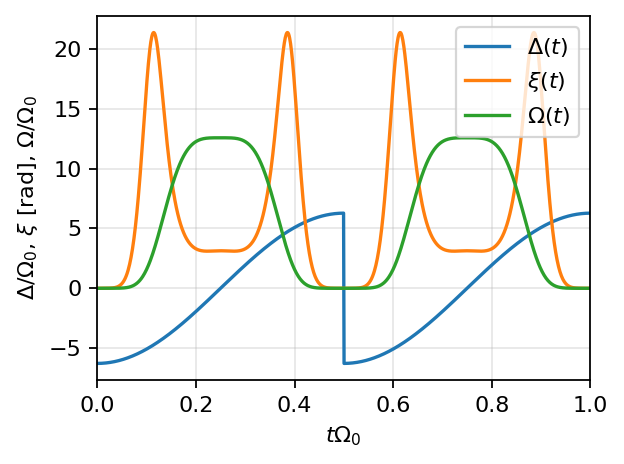

In [4]:
pulse_ansatz = ro.pulses.PulseAnsatz(
    detuning_ansatz=double_sin, phase_ansatz=counterdia, rabi_ansatz=double_exp
)
initial_params=(1,[1.0*2*jnp.pi], [2.003*2*jnp.pi,1.0*2*jnp.pi], [2.003*2*jnp.pi])
fixed_initial_params = (True, [False], [False], [False])
ro.characterization.plot_pulse(pulse_ansatz, initial_params,   plot_rabi= True);

**Testing counterdiabatic gate**

In [7]:
initial_params=(1,[2.0*jnp.pi], [2.0*2.0003*jnp.pi,2.0*jnp.pi], [2*2.003*jnp.pi])
gate = CZGateThreePhotonFull(2000,100,1000,0,0,0)
time_evolved_basis_states = ro.simulation.evolve(gate, pulse_ansatz, initial_params)
gate.process_fidelity(time_evolved_basis_states)

Array(0.99818247, dtype=float64)

**Calculating gate fidelities as function of Omega2 taking into account spontaneous decay**

In [9]:
lifetime80=260.3716142904322
lifetime5p=26e-3
lifetime7s=88e-3
DeltaList=[100,200,400,800,1600,3200,6400]
initial_params=(1,[2.0*jnp.pi,2.0*jnp.pi], [2.0*2.0003*jnp.pi,2.0*jnp.pi,2.0*2.0003*jnp.pi,2.0*jnp.pi], [2*2.003*jnp.pi,2*2.003*jnp.pi])
FLife=[]
for i in range(len(DeltaList)):
    Omega2=2*np.pi*DeltaList[i]
    Omega3=np.sqrt(Omega2*2*2.003*np.pi)
    gate = CZGateThreePhotonFull(Omega2,Omega3,10000,1/lifetime5p/10,1/lifetime7s/10,1/lifetime80/10)
    time_evolved_basis_states = ro.simulation.evolve(gate, pulse_ansatz, initial_params)
    FLife.append(1-gate.process_fidelity(time_evolved_basis_states).item())
FLife

[0.04254066689139768,
 0.02122145126438113,
 0.010639353346049263,
 0.005379806049214175,
 0.0027599664927761003,
 0.0014528480111070108,
 0.0008000238454543007]

**Plot of fidelity as function of Omega2 taking into account spontaneous decay**

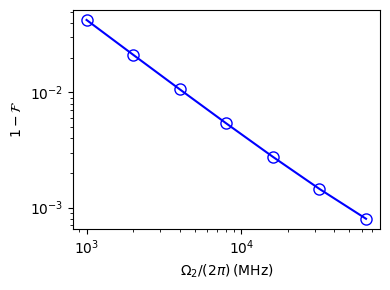

In [10]:
fig, ax = plt.subplots(figsize=(4, 3))

# Plot the first series
ax.plot(jnp.array(DeltaList)*10, FLife,  color='blue', marker='o',mfc='none', markersize=8)

# Add labels, title, and a legend for clarity
ax.set_xlabel(r"$\Omega_2/(2\pi)\,(\rm{MHz})$")
ax.set_ylabel(r"$1-\mathcal{F}$")
ax.set_yscale('log')
ax.set_xscale('log')
#ax.legend() # Displays the labels defined in the scatter calls
fig.tight_layout()
plt.savefig('ThreePhoton_Delta2Life_plot.svg', format='svg')
# Display the plot
plt.show()

**Single-qubit phase shift**

In [13]:
lifetime80=260.3716142904322
lifetime5p=26e-3
lifetime7s=88e-3
DeltaList=[400,800,1600,3200,6400]
initial_params=(1,[2.0*jnp.pi,2.0*jnp.pi], [2.0*2.0003*jnp.pi,2.0*jnp.pi,2.0*2.0003*jnp.pi,2.0*jnp.pi], [2*2.003*jnp.pi,2*2.003*jnp.pi])
Angle=[]
for i in range(len(DeltaList)):
    Omega2=2*np.pi*DeltaList[i]
    Omega3=np.sqrt(Omega2*2*2.003*np.pi)
    gate = CZGateThreePhotonFull(Omega2,Omega3,10000,0/lifetime5p/10,0/lifetime7s/10,0/lifetime80/10)
    time_evolved_basis_states = ro.simulation.evolve(gate, pulse_ansatz, initial_params)
    Angle.append(jnp.angle(time_evolved_basis_states[0][0]).item())
Angle

[-3.141588986310959,
 3.1415926502259386,
 -3.141591081442397,
 -3.141587902883356,
 -3.1415892445920086]

In [12]:
lifetime80=260.3716142904322
lifetime5p=26e-3
lifetime7s=88e-3
DeltaList=[400,800,1600,3200,6400]
initial_params=(1,[2.0*jnp.pi,2.0*jnp.pi], [2.0*2.0003*jnp.pi,2.0*jnp.pi,2.0*2.0003*jnp.pi,2.0*jnp.pi], [2*2.003*jnp.pi,2*2.003*jnp.pi])
Fidentical=[]
for i in range(len(DeltaList)):
    Omega2=2*np.pi*DeltaList[i]
    Omega3=np.sqrt(Omega2*2*2.003*np.pi)
    gate = CZGateThreePhotonFull(Omega2,Omega3,10000,0/lifetime5p/10,0/lifetime7s/10,0/lifetime80/10)
    time_evolved_basis_states = ro.simulation.evolve(gate, pulse_ansatz, initial_params)
    Fidentical.append(1-gate.process_fidelity(time_evolved_basis_states).item())
Fidentical

[0.0003253411549176688,
 9.515162737661065e-05,
 3.140284553149186e-05,
 1.2944259649039225e-05,
 7.1686883883481656e-06]

**Defining the Levine-Pichler gate taking into account decay and finite blockade strength**

In [14]:
class CZGateThreePhotonLevine:

    def __init__(self, Omega2: float,  Omega3: float, Vnn: float, DecayP: float, DecayS: float, DecayR: float):
        self._Omega2 = Omega2
        self._Omega3 = Omega3
        self._Vnn = Vnn
        self._DecayP = DecayP
        self._DecayS = DecayS
        self._DecayR = DecayR

        
        
    def initial_basis_states(self) -> tuple[jnp.ndarray, ...]:
        return jnp.array([1,0,0,0], dtype=complex), jnp.array([1,0,0,0,0,0,0,0,0,0], dtype=complex)

    def hamiltonian_functions_for_basis_states(self) -> tuple[HamiltonianFunction, ...]:
        def hamiltonian1(Delta: float, Xi: float, Omega: float) -> jnp.ndarray:
            """single-atom excitation with states 01,0p,0s,0r"""
            
            DecayP=self._DecayP
            DecayS=self._DecayS
            DecayR=self._DecayR
            Omega2=self._Omega2
            Omega3=self._Omega3
            
            Omega1=Omega2*(Omega*jnp.exp(-1j*Xi))/Omega3
            Omega1C=Omega2*(Omega*jnp.exp(1j*Xi))/Omega3
            return jnp.array(
            [
                   [0,Omega1*0.5,0,0],
                   [Omega1C*0.5,-0.5*1j*DecayP,Omega2*0.5,0],
                   [0,Omega2*0.5,-0.5*1j*DecayS,Omega3*0.5],
                   [0,0,Omega3*0.5,Delta-0.5*1j*DecayR]
                                                          
                ]
            )
        def hamiltonian2(Delta: float, Xi: float, Omega: float) -> jnp.ndarray:
            """
            11 - 1p+p1 - 1s+s1, 1r+r1, 
            11 - 1p+p1 - pp - ps+sp - ss - sr+rs - rr
            11 - 1p+p1 - 1r+r1 - pr+rp - sr+rs - rr
            two-atom excitation with states 11,1p+p1,1s+s1, 1r+r1, pp, ps+sp, pr+rp, ss, sr+rs, rr
            """
            DecayP=self._DecayP
            DecayS=self._DecayS
            DecayR=self._DecayR
            Omega2=self._Omega2
            Omega3=self._Omega3
            Vnn=self._Vnn
            
            Omega1=Omega2*(Omega*jnp.exp(-1j*Xi))/Omega3
            Omega1C=Omega2*(Omega*jnp.exp(1j*Xi))/Omega3
             
            
            return jnp.array(
            [
                   [0,Omega1*0.5*np.sqrt(2),0,0,0,0,0,0,0,0],  #11
                   [Omega1C*0.5*np.sqrt(2),-0.5*1j*DecayP,Omega2*0.5,0,Omega1*0.5*np.sqrt(2),0,0,0,0,0],  #1p+p1 
                   [0,Omega2*0.5,-0.5*1j*DecayS,Omega3*0.5,0,0.5*Omega1,0,0,0,0],  #1s+s1
                   [0,0,Omega3*0.5,Delta-0.5*1j*DecayR,0,0,0.5*Omega1,0,0,0],  #1r+r1
                   [0,Omega1C*0.5*np.sqrt(2),0,0,-1j*DecayP,Omega2*0.5*np.sqrt(2),0,0,0,0],  #pp
                   [0,0,0.5*Omega1C,0,Omega2*0.5*np.sqrt(2),-0.5*1j*(DecayP+DecayS),Omega3*0.5,Omega2*0.5*np.sqrt(2),0,0],  #ps+sp 
                   [0,0,0,0.5*Omega1C,0,Omega3*0.5,Delta-0.5*1j*(DecayP+DecayR),0,Omega2*0.5,0],  #pr+rp
                   [0,0,0,0,0,Omega2*0.5*np.sqrt(2),0,-1j*DecayS,Omega3*0.5*np.sqrt(2),0],  #ss  
                   [0,0,0,0,0,0,Omega2*0.5,Omega3*0.5*np.sqrt(2),Delta-1j*0.5*(DecayS+DecayR),Omega3*0.5*np.sqrt(2)],  #sr+rs
                   [0,0,0,0,0,0,0,0,Omega3*0.5*np.sqrt(2),2*Delta+Vnn-1j*DecayR]   #rr
                ]       
            )
        return hamiltonian1, hamiltonian2


   

    
    def process_fidelity(
        self, final_basis_states: tuple[jnp.ndarray, ...]
    ) -> jnp.ndarray:
        # Obtained diagonal gate matrix
        obtained_gate = jnp.array(
            [
                1,
                final_basis_states[0][0],
                final_basis_states[0][0],
                final_basis_states[1][0],
            ]
        )

        # Targeted diagonal gate matrix
        p = jnp.angle(obtained_gate[1]) 
        t = np.pi

        targeted_gate = jnp.stack(
            [
                1,
                jnp.exp(1j * p),
                jnp.exp(1j * p),
                jnp.exp(1j * (2 * p + t)),
            ]
        )
        return jnp.abs(jnp.vdot(targeted_gate, obtained_gate)) ** 2 / len(targeted_gate) ** 2

**Calculating the dependence of gate fidelity for smooth-shape time-optimal gate**

In [7]:
pulse_ansatz = ro.pulses.PulseAnsatz(
    detuning_ansatz=ro.pulses.const,
    phase_ansatz=ro.pulses.sin_crab,
    rabi_ansatz=ro.pulses.softbox_seventh_order_smoothstep,
)
initial_params=(4.058348807763706, [-0.09393892], [0.73884332, 0.77225565], [2.09722135, 0.19713572])
DeltaList=[400,800,1600,3200,6400]
Omega2=2000
Omega3=Omega2/7.626643597908442
FTO=[]
for i in range(len(DeltaList)):
    Omega2=DeltaList[i]
    Omega3=np.sqrt(Omega2*2*2.003*np.pi)
    gate = CZGateThreePhotonLevine(Omega2,Omega3,10000,0/lifetime5p/10,0/lifetime7s/10,0/lifetime80/10)
    time_evolved_basis_states = ro.simulation.evolve(gate, pulse_ansatz, initial_params)
    FTO.append(1-  gate.process_fidelity(time_evolved_basis_states).item())
FTO

[0.0020387204186241847,
 0.0005195083435677317,
 0.00013092365189149024,
 3.278109184345901e-05,
 8.171870055195818e-06]

**Optimizing smooth-shape time-optimal gate**

In [4]:
pulse_ansatz = ro.pulses.PulseAnsatz(
    detuning_ansatz=ro.pulses.const,
    phase_ansatz=ro.pulses.sin_crab,
    rabi_ansatz=ro.pulses.softbox_seventh_order_smoothstep,
)
initial_params=(4.058348807763706, [-0.09393892], [0.73884332, 0.77225565], [2.09722135, 0.19713572])
DeltaList=[400,800,1600,3200,6400]
lifetime5p=26e-3
lifetime7s=88e-3
lifetime80=260.3716142904322
Omega2=2000
Omega3=Omega2/7.626643597908442
FTOopt=[]
for i in range(len(DeltaList)):
    Omega2=DeltaList[i]
    Omega3=np.sqrt(Omega2*2*2.003*np.pi)
    gate = CZGateThreePhotonLevine(Omega2,Omega3,10000,0/lifetime5p/10,0/lifetime7s/10,0/lifetime80/10)
    opt_result = ro.optimization.optimize(gate, pulse_ansatz, initial_params,  tol=1e-10,num_steps=100)
    FTOopt.append(opt_result.infidelity)
FTOopt

Started optimization using 1 process

proc00: 100%|██████████| 100/100 [12:00<00:00,  7.21s/it, infidelity=1.13e-03, converged=0/1]

=== Optimization finished using Adam ===

Runtime: 738.338 seconds
Gates with infidelity below tol=1.0e-10: 0

Optimized gate:
> infidelity = 1.126915e-03
> parameters = (4.026886916274114, [-0.01266768], [0.87469067 0.71420001], [2.0783067  0.14312566])
> duration = 4.026886916274114
Started optimization using 1 process

proc00: 100%|██████████| 100/100 [11:16<00:00,  6.77s/it, infidelity=3.17e-04, converged=0/1]

=== Optimization finished using Adam ===

Runtime: 690.182 seconds
Gates with infidelity below tol=1.0e-10: 0

Optimized gate:
> infidelity = 3.170036e-04
> parameters = (4.057893877559295, [-0.08420522], [0.76651959 0.7640432 ], [2.1111343  0.19508942])
> duration = 4.057893877559295
Started optimization using 1 process

proc00: 100%|██████████| 100/100 [12:02<00:00,  7.22s/it, infidelity=8.17e-05, converged=0/1]

=== Optimization finished usi

[0.0011269145369527944,
 0.0003170036341542115,
 8.17416862076703e-05,
 2.0553463781269876e-05,
 5.168052841786341e-06]

**Plot of the dependence of gate fidelities on the intermediate Rabi frequency**

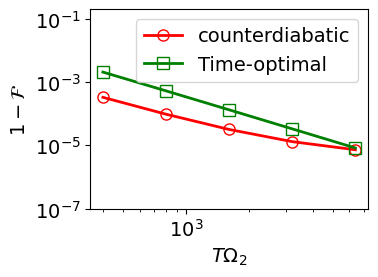

In [48]:
fig, ax = plt.subplots(figsize=(4, 3))
plt.rcParams.update({'font.size': 14})
plt.rcParams['lines.linewidth'] = 2
# Plot the first series

ax.plot(jnp.array(DeltaList), Fidentical, label='counterdiabatic', color='red', marker='o',mfc='none', markersize=8)
ax.plot(jnp.array(DeltaList), FTO, label='Time-optimal', color='green', marker='s',mfc='none', markersize=8)

# Add labels, title, and a legend for clarity
ax.set_xlabel(r"$T\Omega_2$")
ax.set_ylabel(r"$1-\mathcal{F}$")
ax.set_yscale('log')
ax.set_xscale('log')
ax.set_ylim(1e-7, 0.2)
ax.legend() # Displays the labels defined in the scatter calls
fig.tight_layout()
plt.savefig('ThreePhoton_Identical_DeltaOpt_plot.svg', format='svg')
# Display the plot
plt.show()

**Here we take pulse parameters for smooth-shape time-optimal gate optimized for blockade strenght within a single-qubit model**

In [18]:
pulse_ansatz = ro.pulses.PulseAnsatz(
    detuning_ansatz=ro.pulses.const,
    phase_ansatz=ro.pulses.sin_crab,
    rabi_ansatz=ro.pulses.softbox_seventh_order_smoothstep,
)
fixed_initial_params = (True, [False], [False, False], [False, False])
Vnnlist=[100,500,1000,2000,4000]
SmoothParams=[(np.float64(1.110089681492913),([-0.1537824]), ([ 1.45297788, -0.7394141 ]),([8.02814359, 0.2769851 ])),
(np.float64(1.1064437273290284),([-0.13521374]),([1.39706208, 0.71509727]),([8.03545015, 0.2786568 ])),
(np.float64(1.108345457088027),  ([-0.17322966]),   ([1.28144178, 0.7285849 ]), ([8.04546696, 0.28196328])),
(np.float64(1.107753219256768),  ([-0.19917549]),  ([1.20162177, 0.73681584]),([8.045261  , 0.28004245])),
(np.float64(1.1073321187476204), ([-0.21442473]),  ([1.16043418, 0.74140786]),([8.04428056, 0.2786676 ]))]

**Calculating the dependence of gate fidelity for three-photon smooth-shape time-optimal gate**

In [29]:
pulse_ansatz = ro.pulses.PulseAnsatz(
    detuning_ansatz=ro.pulses.const,
    phase_ansatz=ro.pulses.sin_crab,
    rabi_ansatz=ro.pulses.softbox_seventh_order_smoothstep,
)
fixed_initial_params = (True, [False], [False, False], [False, False])
Vnnlist=[100,500,1000,2000,4000]
initial_params=(4.058348807763706, [-0.09393892], [0.73884332, 0.77225565], [2.09722135, 0.19713572])
Vnnlist=[100,500,1000,2000,4000]
SmoothFVlist=[]
lifetime5p=26e-3
lifetime7s=88e-3
lifetime80=260.3716142904322
for i in range(len(Vnnlist)):
    Omega2=2000
    Omega3=np.sqrt(Omega2*2*2.003*np.pi)
    gate = CZGateThreePhotonLevine(Omega2,Omega3,Vnnlist[i],0/lifetime5p/10,0/lifetime7s/10,0/lifetime80/10)   
    time_evolved_basis_states = ro.simulation.evolve(gate, pulse_ansatz, initial_params)
    SmoothFVlist.append(1-  gate.process_fidelity(time_evolved_basis_states).item())
SmoothFVlist

[0.00011848066566921833,
 0.0001136868526784296,
 0.00011478346133386719,
 0.00011524933407858207,
 0.00011548274301975692]

**Calculating the dependence of gate fidelity for three-photon optimized counterdiabatic gate**

In [36]:
pulse_ansatz = ro.pulses.PulseAnsatz(
    detuning_ansatz=double_sin, phase_ansatz=counterdia, rabi_ansatz=double_exp
)
fixed_initial_params = (True, [False], [False, False,False, False], [False, False])
Vnnlist=[100,500,1000,2000,4000]
initial_params=(1,[2.0*jnp.pi,2.0*jnp.pi], [2.0*2.0003*jnp.pi,2.0*jnp.pi,2.0*2.0003*jnp.pi,2.0*jnp.pi], [2*2.003*jnp.pi,2*2.003*jnp.pi])
CounterFVlist=[]
lifetime5p=26e-3
lifetime7s=88e-3
lifetime80=260.3716142904322
for i in range(len(Vnnlist)):
    Omega2=2000
    Omega3=np.sqrt(Omega2*2*2.003*np.pi)
    gate = CZGateThreePhotonFull(Omega2,Omega3,Vnnlist[i],0/lifetime5p/10,0/lifetime7s/10,0/lifetime80/10)   
    opt_result = ro.optimization.optimize(gate, pulse_ansatz, initial_params,  tol=1e-10,num_steps=300)
    CounterFVlist.append(opt_result.infidelity)
CounterFVlist

Started optimization using 1 process

proc00: 100%|██████████| 300/300 [09:46<00:00,  1.96s/it, infidelity=1.54e-03, converged=0/1] 

=== Optimization finished using Adam ===

Runtime: 597.158 seconds
Gates with infidelity below tol=1.0e-10: 0

Optimized gate:
> infidelity = 1.537156e-03
> parameters = (1.5091788717750911, [6.16072726 7.18305235], [12.6445837   7.79571306 11.94401087  5.8011123 ], [10.33069789 10.73167203])
> duration = 1.5091788717750911
Started optimization using 1 process

proc00: 100%|██████████| 300/300 [11:21<00:00,  2.27s/it, infidelity=8.48e-05, converged=0/1]

=== Optimization finished using Adam ===

Runtime: 689.791 seconds
Gates with infidelity below tol=1.0e-10: 0

Optimized gate:
> infidelity = 8.484561e-05
> parameters = (2.652218549890589, [6.07657243 6.91424046], [13.91248124  6.09789893 12.36542283  6.18037045], [12.34466394 10.90568892])
> duration = 2.652218549890589
Started optimization using 1 process

proc00: 100%|██████████| 300/300 [07:45<00:00

[0.001537156463944811,
 8.484560653099216e-05,
 6.21492533292578e-05,
 6.732735886294527e-05,
 0.000103159506891215]

**Plot comparison of the gate fidelities for finite blockade strength**

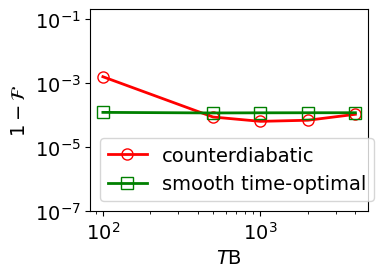

In [37]:
fig, ax = plt.subplots(figsize=(4, 3))
plt.rcParams.update({'font.size': 14})
plt.rcParams['lines.linewidth'] = 2
# Plot the first series

ax.plot(jnp.array(Vnnlist), CounterFVlist, label='counterdiabatic', color='red', marker='o',mfc='none', markersize=8)
ax.plot(jnp.array(Vnnlist), SmoothFVlist, label='smooth time-optimal', color='green', marker='s',mfc='none', markersize=8)

# Add labels, title, and a legend for clarity
ax.set_xlabel(r"$T\sf{B}$")
ax.set_ylabel(r"$1-\mathcal{F}$")
ax.set_yscale('log')
ax.set_xscale('log')
ax.set_ylim(1e-7, 0.2)
ax.legend() # Displays the labels defined in the scatter calls
fig.tight_layout()
plt.savefig('ThreePhoton_V_plot.svg', format='svg')
# Display the plot
plt.show()